In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [14]:
def load_data():

    folder = "../Preprocessing-FeatureExtraction/cleaned-data/"
    csv_files = glob.glob(os.path.join(folder, "*.csv"))
    
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        df['state'] = os.path.splitext(os.path.basename(file))[0]
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    df = data.dropna()
    
    # Create sentiment labels: 0=negative (1-2), 1=neutral (3), 2=positive (4-5)
    df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))
    
    print(f"Loaded {len(df)} reviews from {len(dfs)} states.")
    return df

In [15]:
class LayeredStarClassifier:
    """
    Two-layer hierarchical classifier:
    Layer 1: Split reviews into low/mid (1-3) vs mid/high (3-5)
    Layer 2A: For low/mid group, predict 1-3
    Layer 2B: For mid/high group, predict 3-5
    """

    def __init__(self, max_features=10000, ngram_range=(1, 2)):
        # Layer 1: Coarse group classifier (1–3 vs 3–5)
        self.group_classifier = LogisticRegression(max_iter=1000, random_state=42)

        # Layer 2A: Fine classifier for 1–3
        self.lowmid_classifier = LogisticRegression(max_iter=1000, random_state=42)

        # Layer 2B: Fine classifier for 3–5
        self.midhigh_classifier = LogisticRegression(max_iter=1000, random_state=42)

        # Vectorizers
        self.group_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.lowmid_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.midhigh_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

    def fit(self, X_train, y_train):
        if not isinstance(X_train, pd.Series):
            X_train = pd.Series(X_train)
        if not isinstance(y_train, pd.Series):
            y_train = pd.Series(y_train)

        print("\n=== Training Layer 1: Group Classifier (1-3 vs 3-5) ===")
        group_labels = y_train.apply(lambda x: 0 if x <= 3 else 1)
        X_train_group = self.group_vectorizer.fit_transform(X_train)
        self.group_classifier.fit(X_train_group, group_labels)
        print("Layer 1 training accuracy:",
              accuracy_score(group_labels, self.group_classifier.predict(X_train_group)))

        # -----------------------
        # Layer 2A: 1–3 classifier
        # -----------------------
        lowmid_mask = y_train <= 3
        X_train_lowmid = X_train[lowmid_mask]
        y_train_lowmid = y_train[lowmid_mask]

        print("\n=== Training Layer 2A: Low/Mid Classifier (1,2,3) ===")
        X_train_lowmid_tfidf = self.lowmid_vectorizer.fit_transform(X_train_lowmid)
        self.lowmid_classifier.fit(X_train_lowmid_tfidf, y_train_lowmid)
        print("Layer 2A training accuracy:",
              accuracy_score(y_train_lowmid,
                             self.lowmid_classifier.predict(X_train_lowmid_tfidf)))

        # -----------------------
        # Layer 2B: 3–5 classifier
        # -----------------------
        midhigh_mask = y_train >= 3
        X_train_midhigh = X_train[midhigh_mask]
        y_train_midhigh = y_train[midhigh_mask]

        print("\n=== Training Layer 2B: Mid/High Classifier (3,4,5) ===")
        X_train_midhigh_tfidf = self.midhigh_vectorizer.fit_transform(X_train_midhigh)
        self.midhigh_classifier.fit(X_train_midhigh_tfidf, y_train_midhigh)
        print("Layer 2B training accuracy:",
              accuracy_score(y_train_midhigh,
                             self.midhigh_classifier.predict(X_train_midhigh_tfidf)))

        print("\n=== Training Complete ===")

    # def predict(self, X_test):
    #     if not isinstance(X_test, pd.Series):
    #         X_test = pd.Series(X_test)

    #     n = len(X_test)
    #     predictions = np.zeros(n, dtype=int)

    #     # Layer 1 predictions
    #     X_test_group = self.group_vectorizer.transform(X_test)
    #     group_pred = self.group_classifier.predict(X_test_group)

    #     # Low/Mid group
    #     lowmid_mask = group_pred == 0
    #     if lowmid_mask.sum() > 0:
    #         X_lowmid = X_test[lowmid_mask]
    #         X_lowmid_tfidf = self.lowmid_vectorizer.transform(X_lowmid)
    #         predictions[lowmid_mask] = self.lowmid_classifier.predict(X_lowmid_tfidf)

    #     # Mid/High group
    #     midhigh_mask = group_pred == 1
    #     if midhigh_mask.sum() > 0:
    #         X_midhigh = X_test[midhigh_mask]
    #         X_midhigh_tfidf = self.midhigh_vectorizer.transform(X_midhigh)
    #         predictions[midhigh_mask] = self.midhigh_classifier.predict(X_midhigh_tfidf)

    #     return predictions
        
    def predict_proba(self, X_test):
        """
        Predict probability distribution over 1-5 stars using soft routing.
        Returns array of shape (n_samples, 5).
        """
        if not isinstance(X_test, pd.Series):
            X_test = pd.Series(X_test)

        n = len(X_test)
        proba = np.zeros((n, 5))

        # ---- Layer 1: group probabilities ----
        X_group = self.group_vectorizer.transform(X_test)
        group_proba = self.group_classifier.predict_proba(X_group)
        # group_proba[:,0] = P(low/mid), group_proba[:,1] = P(mid/high)

        # ---- Layer 2A: predict probs for 1–3 ----
        X_lowmid = self.lowmid_vectorizer.transform(X_test)
        lowmid_proba_full = np.zeros((n, 3))
        lowmid_proba_full[:] = self.lowmid_classifier.predict_proba(X_lowmid)

        # ---- Layer 2B: predict probs for 3–5 ----
        X_midhigh = self.midhigh_vectorizer.transform(X_test)
        midhigh_proba_full = np.zeros((n, 3))
        midhigh_proba_full[:] = self.midhigh_classifier.predict_proba(X_midhigh)

        # ---- Combine weighted probabilities ----
        for i in range(n):
            p_lowmid = group_proba[i, 0]
            p_midhigh = group_proba[i, 1]

            # Map class indices: lowmid → stars 1,2,3; midhigh → 3,4,5
            proba[i, 0:3] += p_lowmid * lowmid_proba_full[i]  # 1–3
            proba[i, 2:5] += p_midhigh * midhigh_proba_full[i]  # 3–5

            # Note: both add to index 2 (the 3-star slot), naturally averaging it.

        # Normalize to sum to 1 per row
        proba /= proba.sum(axis=1, keepdims=True)

        return proba


    def predict(self, X_test):
        """
        Predict the most probable star rating using soft routing.
        """
        proba = self.predict_proba(X_test)
        stars = np.array([1, 2, 3, 4, 5])
        return stars[np.argmax(proba, axis=1)]

In [16]:
def evaluate_classifier(y_true, y_pred, classifier_name="Classifier"):
    """Evaluate and print classifier performance"""
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n{classifier_name} Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Macro-F1: {macro_f1:.4f}")
    
    print("\nPer-Class Performance:")
    report = classification_report(y_true, y_pred, labels=[1, 2, 3, 4, 5], output_dict=True)
    for star in [1, 2, 3, 4, 5]:
        if str(star) in report:
            print(f"  {star} stars - Precision: {report[str(star)]['precision']:.4f}, "
                  f"Recall: {report[str(star)]['recall']:.4f}, "
                  f"F1: {report[str(star)]['f1-score']:.4f}")
    
    return accuracy, macro_f1, report

In [17]:
def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[1, 2, 3, 4, 5],
                yticklabels=[1, 2, 3, 4, 5])
    plt.title(title, fontsize=16)
    plt.ylabel('True Star Rating', fontsize=12)
    plt.xlabel('Predicted Star Rating', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/cl/5mfvhcls2nv2h9gy15m04b640000gn/T/ipykernel_8364/2893345601.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))


Loaded 5222860 reviews from 20 states.
LAYERED STAR RATING CLASSIFIER

Sampling 500000 reviews...

Class distribution in sample:
1.0    100000
2.0    100000
3.0    100000
4.0    100000
5.0    100000
Name: stars, dtype: int64

Training set: 450000 reviews
Test set: 50000 reviews

=== Training Layer 1: Group Classifier (1-3 vs 3-5) ===
Layer 1 training accuracy: 0.9088577777777778

=== Training Layer 2A: Low/Mid Classifier (1,2,3) ===
Layer 2A training accuracy: 0.7137777777777777

=== Training Layer 2B: Mid/High Classifier (3,4,5) ===
Layer 2B training accuracy: 0.7208222222222223

=== Training Complete ===

Making predictions on test set...

Layered Classifier Results:
  Accuracy: 0.6073
  Macro-F1: 0.6028

Per-Class Performance:
  1 stars - Precision: 0.7272, Recall: 0.7529, F1: 0.7398
  2 stars - Precision: 0.5661, Recall: 0.4973, F1: 0.5295
  3 stars - Precision: 0.4723, Recall: 0.6854, F1: 0.5593
  4 stars - Precision: 0.5926, Recall: 0.3778, F1: 0.4614
  5 stars - Precision: 0.724

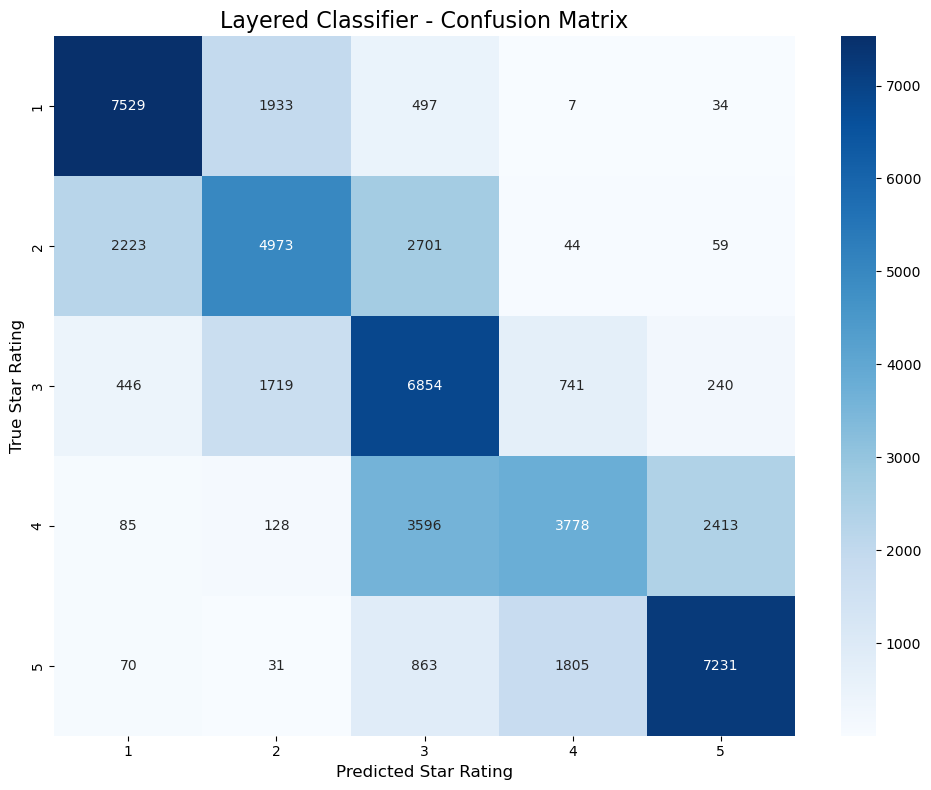


COMPARISON WITH BASELINE LOGISTIC REGRESSION

Baseline Logistic Regression Results:
  Accuracy: 0.6217
  Macro-F1: 0.6199

Per-Class Performance:
  1 stars - Precision: 0.7173, Recall: 0.7575, F1: 0.7369
  2 stars - Precision: 0.5497, Recall: 0.5310, F1: 0.5402
  3 stars - Precision: 0.5596, Recall: 0.5376, F1: 0.5484
  4 stars - Precision: 0.5581, Recall: 0.5426, F1: 0.5502
  5 stars - Precision: 0.7080, Recall: 0.7399, F1: 0.7236


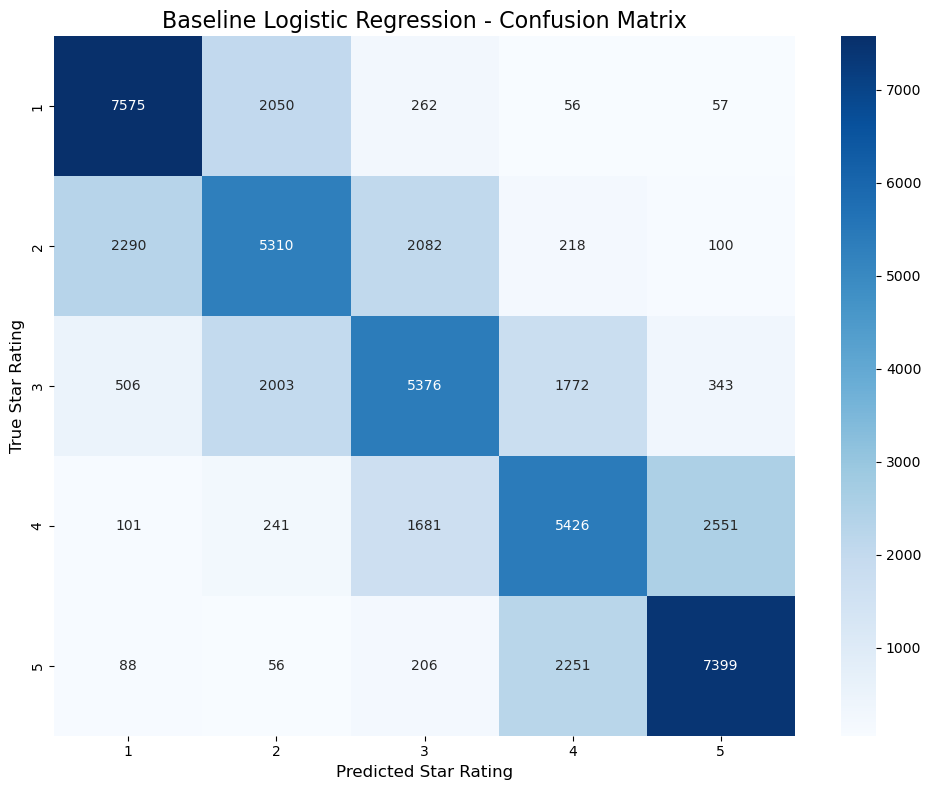


FINAL COMPARISON
Metric                         Layered         Baseline        Difference     
------------------------------------------------------------
Accuracy                       0.6073          0.6217          -0.0144
Macro-F1                       0.6028          0.6199          -0.0171


In [18]:
def main(data, n=500000):
    """
    Main function to train and evaluate layered classifier
    
    Args:
        data: Full dataset
        n: Sample size to use
    """
    print("="*60)
    print("LAYERED STAR RATING CLASSIFIER")
    print("="*60)
    
    # Sample data
    print(f"\nSampling {n} reviews...")
    # data_sample = data.sample(n=min(n, len(data)), random_state=42)
    # Balanced sampling
    samples_per_class = min(n // data['stars'].nunique(), data['stars'].value_counts().min())
    data_sample = (
        data.groupby('stars', group_keys=False)
            .apply(lambda x: x.sample(n=samples_per_class))
            .reset_index(drop=True)
    )
    
    print(f"\nClass distribution in sample:")
    print(data_sample['stars'].value_counts().sort_index())
    
    # Prepare features and labels
    X = data_sample['clean_text']
    y = data_sample['stars'].astype(int)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {len(X_train)} reviews")
    print(f"Test set: {len(X_test)} reviews")
    
    # Initialize and train layered classifier
    layered_clf = LayeredStarClassifier(max_features=10000, ngram_range=(1, 2))
    layered_clf.fit(X_train, y_train)
    
    # Make predictions
    print("\nMaking predictions on test set...")
    y_pred = layered_clf.predict(X_test)
    
    # Evaluate
    accuracy, macro_f1, report = evaluate_classifier(
        y_test, y_pred, 
        classifier_name="Layered Classifier"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(
        y_test, y_pred,
        title="Layered Classifier - Confusion Matrix",
        save_path="layered_classifier_confusion_matrix.png"
    )
    
    # Compare with baseline (optional)
    print("\n" + "="*60)
    print("COMPARISON WITH BASELINE LOGISTIC REGRESSION")
    print("="*60)
        
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    baseline = LogisticRegression(max_iter=1000, random_state=42)
    baseline.fit(X_train_tfidf, y_train)
    y_pred_baseline = baseline.predict(X_test_tfidf)
    
    baseline_accuracy, baseline_f1, baseline_report = evaluate_classifier(
        y_test, y_pred_baseline,
        classifier_name="Baseline Logistic Regression"
    )
    
    plot_confusion_matrix(
        y_test, y_pred_baseline,
        title="Baseline Logistic Regression - Confusion Matrix",
        save_path="baseline_confusion_matrix.png"
    )
    
    # Summary comparison
    print("\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    print(f"{'Metric':<30} {'Layered':<15} {'Baseline':<15} {'Difference':<15}")
    print("-"*60)
    print(f"{'Accuracy':<30} {accuracy:<15.4f} {baseline_accuracy:<15.4f} {accuracy - baseline_accuracy:+.4f}")
    print(f"{'Macro-F1':<30} {macro_f1:<15.4f} {baseline_f1:<15.4f} {macro_f1 - baseline_f1:+.4f}")
    
    return layered_clf, report, baseline_report

# ============================================================================
# 5. RUN
# ============================================================================

if __name__ == "__main__":
    # Load data
    df = load_data()
    
    # Train and evaluate
    layered_clf, layered_report, baseline_report = main(df, n=500000)